# Homework 1
This homework is designed to see what you remember from last year. You will have all the first weeks labs, and you can work at home if needed.  We will use this homework as a way of setting the level for the first part of the course. So, please try to do these without **help**, you will get lots of opportunities to make up the grades and to go though the solutions line by line



# Week 1: Start using Python

Even as we start with simple examples this week, implement the good practice tips discussed in the lecture:

- lay code out neatly

- include short comment lines explaining code, this is more for you than anything else

- import modules using an alias such as *import numpy as np*



## Exercise 1: Projective motion
Write a function to calculate the height and displacement of a projective launched with a velocity V and angle A at time t. You can use gravity as a defined parameter within the fucntion but allow it to be set by the call, the function should return the X and Y position. <br>
The height is given by <br>
 $ h = v_0 sin(\theta) t - \frac{1}{2} g t^2$
 <br>
 The x position is given by <br>
 $ x = v_0 cos(\theta) t $

In [ ]:
import numpy as np

# given that the angle is in degrees
def suvat(V, A, T, g=9.81):
  # V-velocity, A-angle, T-time, g-gravity
  y = V*np.sin(A*np.pi/180)*T - 0.5 * g * T**2
  x = V*np.cos(A*np.pi/180)*T
  return x, y

## Exercise 1a: Plot the motion

Call the function defined above using a velocity of $10 ms^{-1}$ and an angle of $45\degree$, Using a while loop stop the function once the porjectil hits the ground (or just below it if your delta t is large) store this data as a 2D numpy array, perform the task again using the velocity of $20 ms^{-1}$ and angle $45\degree$ and again store this data.
Once you have the two data sets, plot them with X and Y labels, a lengend and use red and black as the colours for the data sets.

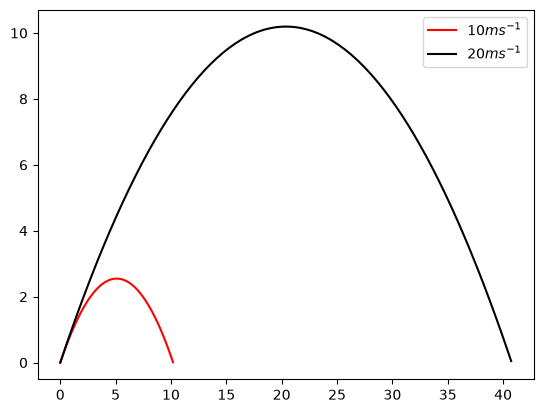

In [2]:
import matplotlib.pyplot as plt

t = 0
v1 = 10
A = 45
v2 = 20

g=9.81

def calc(v, A, t, g):
  x = []
  y = []

  while (len(y)==0) or (y[-1]>=0):
    xtemp, ytemp = suvat(v, A, t, g)

    if ytemp < 0:
      break

    x.append(xtemp)
    y.append(ytemp)

    t+=0.02

  xy = np.vstack((np.array(x), np.array(y)))
  return xy

set1 = calc(v1, A, t, g)
set2 = calc(v2, A, t, g)

plt.plot(set1[0], set1[1], color = 'r', label = '$10 ms^{-1}$')
plt.plot(set2[0], set2[1], color = 'k', label = '$20 ms^{-1}$')

plt.legend()
plt.show()


## Exercise 2: Sequence analysis
Given a DNA sequence of A's,'G's, T's and C's find and prrint the postions at which the sequence "A","C","G","T" occurs.


In [3]:
# This code will load the DNA sequence in to a list called data
import pickle
with open('my_list.pkl', 'rb') as f:
    data = pickle.load(f)
# print(data)

x = ['A', 'C', 'G', 'T']
for i in range(0,len(data)-4):
  # iterate through every set of 4 up until the last 4
  segment = data[i:i+4]
  if segment == x:
    # Comparison
    print(i)

148
261
726
882


## Exercise 3: Calculate a series expansion
The series expansion for cos(x) can be written as:

$$\cos(x) = \large{\large{\sum_{n=0}^{\infty} (-1)^{n} \frac{x^{2n}}{(2n)!}=1-\frac{x^{2}}{2!}+\frac{x^{4}}{4!}-\frac{x^{6}}{6!}+...}}$$

Write a Python programme that compares the value of cos(x) calculated with the first 4 terms of the series expansion above to that returned by `numpy.cos(x)`.
- Your script should prompt the user for a value of x (in degrees)
- Print both values of cos(x), their absolute difference and the percentage difference (relative to the value of `numpy.cos(x)`) to the screen
- How does the approximate series perform?

Convert your program in to a function which takes two inputs, the first is the angle, the second is the number of terms to calcualate the expansion to.  The function should return the caluclated value of cos and the difference between the expansion and the cos function.

Tip: numpy has useful functions for converting radians to degrees and visa versa.

In [4]:
import math

def calcx(x, n):
  # Calculate macl series per term
  a = (-1)**n * ((x)**(2*n))/(math.factorial(2*n))
  return a

def comparison(angle, nterms):
  sums = []
  x = np.deg2rad(angle)
  n = nterms

  # using numpy function
  cos = np.cos(x)

  for i in range(n):
    temp = calcx(x, i)
    sums.append(temp)
  # print(sums)
  calculated = sum(sums)

  # calculate differences
  absdif = abs(cos-calculated)
  perdif = 100 * absdif/ cos

  summary = f'Cosine function = {cos}, Maclaurin Expansion = {calculated}, Absolute difference = {absdif}, Percentage difference = {perdif}%'
  return summary

comparison(20, 4)

'Cosine function = 0.9396926207859084, Maclaurin Expansion = 0.9396926153264376, Absolute difference = 5.4594708753796795e-09, Percentage difference = 5.809847555058665e-07%'

## Exercise 4: Convert a number to a binary string
Write a function to convert an integer to a binary string. To convert integer to binary, start with the integer in question and divide it by 2 keeping track of the quotient and the remainder. Continue dividing the quotient by 2 until you get a quotient of zero.

The quotient operator is '//' and the remainder operator is '%'
<br>
<br>


#### This is the psedocode for converting to binary: <br>

set a number to convert to binary <br>
calculate the remainder when the number is divided by 2 <br>
Store this number (it must be 0 or 1) <br>
Perform a floor division of the number by 2 (number // 2) and set number to this value <br>
Repeat the above 2 steps until number is 0 <br>



In [5]:
def int2bi(x):
  number = []
  while x != 0:
    number.append(x%2)
    x = x//2
  number.reverse()
  return number

int2bi(56)

[1, 1, 1, 0, 0, 0]